In [1]:
import os, logging, sys, cv2
import mediapipe as mp
from datetime import datetime

sys.path.append(os.path.abspath(".."))

from src.utils import save_landmarks_to_csv, get_landmarks_from_image, normalize_landmarks, Landmark

2026-01-29 19:07:51.453639: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-29 19:07:51.453684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-29 19:07:51.454887: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-29 19:07:51.461099: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
import cv2, warnings
import mediapipe as mp
import numpy as np

warnings.filterwarnings('ignore')
logging.getLogger('mediapipe').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Inicializar MediaPipe
mp_pose = mp.solutions.pose
pose_processor = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# 1. Cargar imágenes
img_orig = cv2.cvtColor(cv2.imread("/nas/antoniodetoro/qwen/Qwen-Image-Edit-Angles-2/datos/MultiViewVisibleImagesHPE_Custom/test/00_16/00_16_1680262440734_rgb.png"), cv2.COLOR_BGR2RGB)
img_gen = cv2.cvtColor(cv2.imread("/nas/antoniodetoro/qwen/Qwen-Image-Edit-Angles-2/datos/MultiViewVisibleImagesHPE_Custom/00_17/to_00_16/Step_6_fake_00_16_from_00_17_1680262440734_rgb.png"), cv2.COLOR_BGR2RGB)
# img_gen = cv2.cvtColor(cv2.imread("/nas/antoniodetoro/qwen/Qwen-Image-Edit-Angles-2/datos/MultiViewVisibleImagesHPE_Custom/test/00_16/00_16_1680262440734_rgb.png"), cv2.COLOR_BGR2RGB)
# 2. Extraer y Normalizar
raw_orig = get_landmarks_from_image(img_orig, pose_processor)
raw_gen = get_landmarks_from_image(img_gen, pose_processor)

pose_a = normalize_landmarks(raw_orig)["pose"]
pose_b = normalize_landmarks(raw_gen)["pose"]

# Convertir a arrays de NumPy (N, 2) para facilitar cálculos
pts_a = np.array([[lm.x, lm.y] for lm in pose_a])
pts_b = np.array([[lm.x, lm.y] for lm in pose_b])

# MÉTRICA DE DISPARIDAD RÁPIDA (Men Per Joint Position Error)
distancias = np.linalg.norm(pts_a - pts_b, axis=1)
print(f"Disparidad Media: {np.mean(distancias):.2f} unidades")
print(f"Punto con mayor error: Landmark {np.argmax(distancias)}")

Disparidad Media: 3.38 unidades
Punto con mayor error: Landmark 12


I0000 00:00:1769711626.647041 3357298 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1769711626.708979 3397723 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.05), renderer: NVIDIA A30/PCIe/SSE2
W0000 00:00:1769711626.779158 3397660 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769711626.814865 3397683 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### 1. Precisión Posicional (MPJPE y PCK)

Estas métricas evalúan la exactitud geométrica pura de los puntos clave.

*   **Intución:** ¿Qué tan lejos, en media, están los puntos predichos de los reales?
*   **MPJPE (Mean Per Joint Position Error):** Es el promedio de la distancia euclidiana entre cada par de puntos correspondientes. Se mide en píxeles (en nuestro espacio normalizado de 100x100).
    $$ MPJPE = \frac{1}{N} \sum_{i=1}^{N} \| \hat{y}_i - y_i \|_2 $$
*   **PCK (Percentage of Correct Keypoints):** Es el porcentaje de puntos que se consideran "correctos" porque su error es menor a un umbral $\alpha$ (en nuestro caso, 5 píxeles). Es una medida de robustez.
    $$ PCK@\alpha = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}(\| \hat{y}_i - y_i \|_2 < \alpha) \times 100 $$

In [15]:
def calculate_positional_error(pts1, pts2, threshold=5.0):
    # Distancia euclidiana punto a punto
    distances = np.linalg.norm(pts1 - pts2, axis=1)
    
    # MPJPE: Mean Per Joint Position Error
    mpjpe = np.mean(distances)
    
    # PCK: Percentage of Correct Keypoints (dentro del umbral de 5 píxeles)
    pck = np.mean(distances < threshold) * 100
    
    return mpjpe, pck

error_medio, precision_pck = calculate_positional_error(pts_a, pts_b)

print(f"--- Precisión de Posición ---")
print(f"Error Medio (MPJPE): {error_medio:.2f} px")
print(f"Puntos correctos (PCK@5): {precision_pck:.2f}%")

--- Precisión de Posición ---
Error Medio (MPJPE): 3.38 px
Puntos correctos (PCK@5): 75.76%


### 2. Coherencia Anatómica (Bone Length Consistency)

Esta métrica evalúa si la IA ha respetado la estructura física del cuerpo humano, independientemente de la posición en el espacio.

*   **Intuición:** Si el brazo izquierdo mide 30px en la imagen original, debería medir aproximadamente lo mismo en la generada, incluso si el brazo se ha movido. Si la longitud cambia drásticamente, la IA ha deformado el cuerpo ("efecto chicle").
*   **Matemáticas:** Calculamos la longitud de cada hueso $L$ como la distancia entre sus dos articulaciones conectadas y medimos el error relativo porcentual.
    $$ Error_{relativo} = \frac{ | L_{gen} - L_{orig} | }{ L_{orig} } \times 100 $$

In [16]:
def get_bone_lengths(pts):
    # Definimos conexiones: (Hombro-Codo), (Codo-Muñeca), (Cadera-Rodilla)
    connections = [(11, 13), (13, 15), (12, 14), (14, 16), (23, 25), (25, 27)]
    lengths = []
    for i, j in connections:
        dist = np.linalg.norm(pts[i] - pts[j])
        lengths.append(dist)
    return np.array(lengths)

bones_a = get_bone_lengths(pts_a)
bones_b = get_bone_lengths(pts_b)

# Error relativo en la longitud de los huesos (porcentaje de deformación)
bone_disparity = np.mean(np.abs(bones_a - bones_b) / bones_a) * 100

print(f"--- Coherencia Anatómica ---")
print(f"Deformación promedio de miembros: {bone_disparity:.2f}%")

--- Coherencia Anatómica ---
Deformación promedio de miembros: 3.21%


### 3. Similitud de Gesto (Cosine Similarity)

Esta métrica evalúa si la **intención** o **forma** de la pose se mantiene, ignorando desplazamientos o escalas absolutas.

*   **Intuición:** Tratamos toda la pose como un vector de alta dimensión. Medimos el ángulo entre el vector de la pose original y la generada. Si apuntan en la misma "dirección" matemática, el gesto es el mismo. Es decir, medimos el ángulo entre articulaciones.
*   **Matemáticas:** Usamos la similitud de coseno, que varía entre -1 (opuestos) y 1 (idénticos).
    $$ Similitud = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|} $$

In [17]:
from scipy.spatial.distance import cosine

# Aplanamos los puntos a vectores de 66 elementos (33x, 33y)
vec_a = pts_a.flatten()
vec_b = pts_b.flatten()

# La similitud de coseno va de 0 a 1 (1 es identidad total)
similitud = 1 - cosine(vec_a, vec_b)

print(f"--- Similitud de Gesto ---")
print(f"Índice de similitud de orientación: {similitud:.4f}")

--- Similitud de Gesto ---
Índice de similitud de orientación: 0.9990


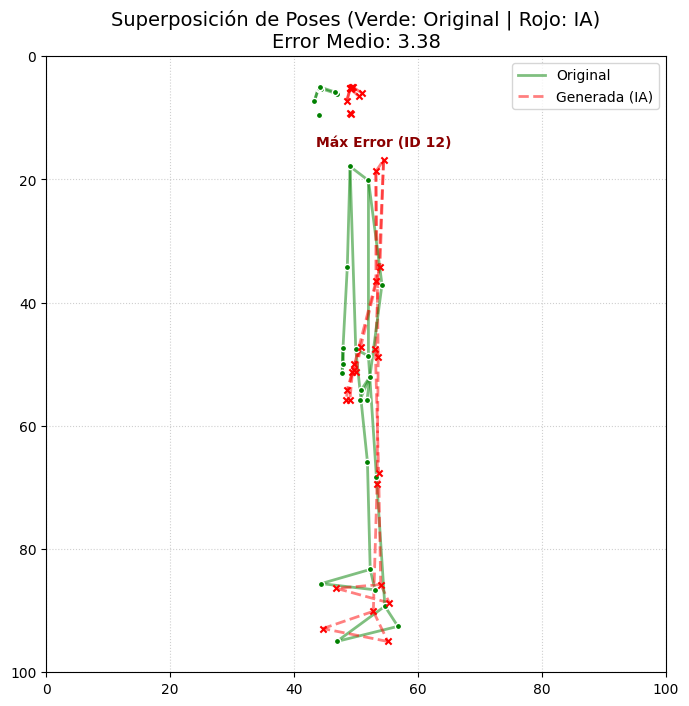

Disparidad Media: 3.38 unidades
Punto con mayor error: Landmark 12


In [18]:
import matplotlib.pyplot as plt

# 1. Calcular métricas
distancias = np.linalg.norm(pts_a - pts_b, axis=1)
error_medio = np.mean(distancias)

# 2. Configurar visualización (Lienzo de 100x100 ampliado para ver detalles)
plt.figure(figsize=(8, 8))
plt.title(f"Superposición de Poses (Verde: Original | Rojo: IA)\nError Medio: {error_medio:.2f}", fontsize=14)

# Definir las conexiones del esqueleto de MediaPipe (para dibujar líneas)
CONNECTIONS = mp_pose.POSE_CONNECTIONS

# Dibujar conexiones (huesos)
for connection in CONNECTIONS:
    idx1, idx2 = connection
    # Pose Original (Verde)
    plt.plot([pts_a[idx1, 0], pts_a[idx2, 0]], [pts_a[idx1, 1], pts_a[idx2, 1]], 
             color='green', alpha=0.5, linewidth=2, label='Original' if idx1==0 else "")
    # Pose Generada (Rojo)
    plt.plot([pts_b[idx1, 0], pts_b[idx2, 0]], [pts_b[idx1, 1], pts_b[idx2, 1]], 
             color='red', alpha=0.5, linewidth=2, linestyle='--', label='IA' if idx1==0 else "")

# Dibujar puntos (articulaciones)
plt.scatter(pts_a[:, 0], pts_a[:, 1], color='green', s=20, edgecolors='white', zorder=5)
plt.scatter(pts_b[:, 0], pts_b[:, 1], color='red', s=20, marker='x', zorder=5)

# Anotar el punto de mayor error
peor_idx = np.argmax(distancias)
plt.annotate(f"Máx Error (ID {peor_idx})", (pts_b[peor_idx, 0], pts_b[peor_idx, 1]), 
             textcoords="offset points", xytext=(0,10), ha='center', color='darkred', weight='bold')

# Ajustes de eje (Invertimos Y porque en imágenes el 0,0 es arriba-izquierda)
plt.xlim(0, 100)
plt.ylim(100, 0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(['Original', 'Generada (IA)'])
plt.show()

print(f"Disparidad Media: {error_medio:.2f} unidades")
print(f"Punto con mayor error: Landmark {peor_idx}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, os

# Cargar el CSV (ajusta el nombre al que generaste)
csv_path = "../src/resultados_vista_16.csv"
df = pd.DataFrame()

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    # Filtrar solo las filas donde hubo una comparación válida
    df_valid = df[df['status'] == 'OK'].copy()
    print(f"Dataset cargado: {len(df)} entradas totales, {len(df_valid)} comparaciones válidas.")
else:
    print("Archivo CSV no encontrado.")

Dataset cargado: 990 entradas totales, 990 comparaciones válidas.


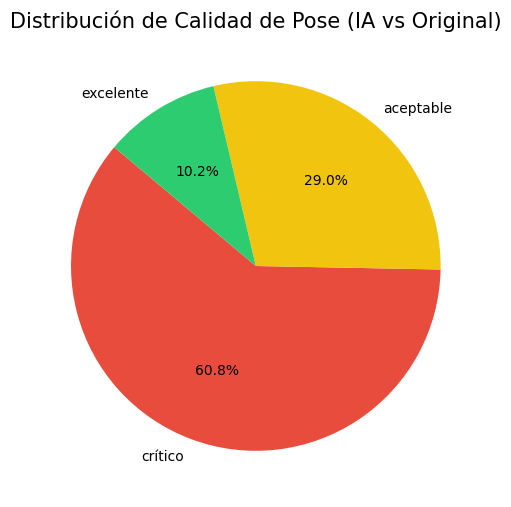

In [3]:
# Configurar estilo
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))

# Contar frecuencias de calidad
calidad_counts = df_valid['calidad'].value_counts()
colors = {'excelente': '#2ecc71', 'aceptable': '#f1c40f', 'crítico': '#e74c3c'}

plt.pie(calidad_counts, labels=calidad_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=[colors.get(x, '#3498db') for x in calidad_counts.index])

plt.title('Distribución de Calidad de Pose (IA vs Original)', fontsize=15)
plt.show()

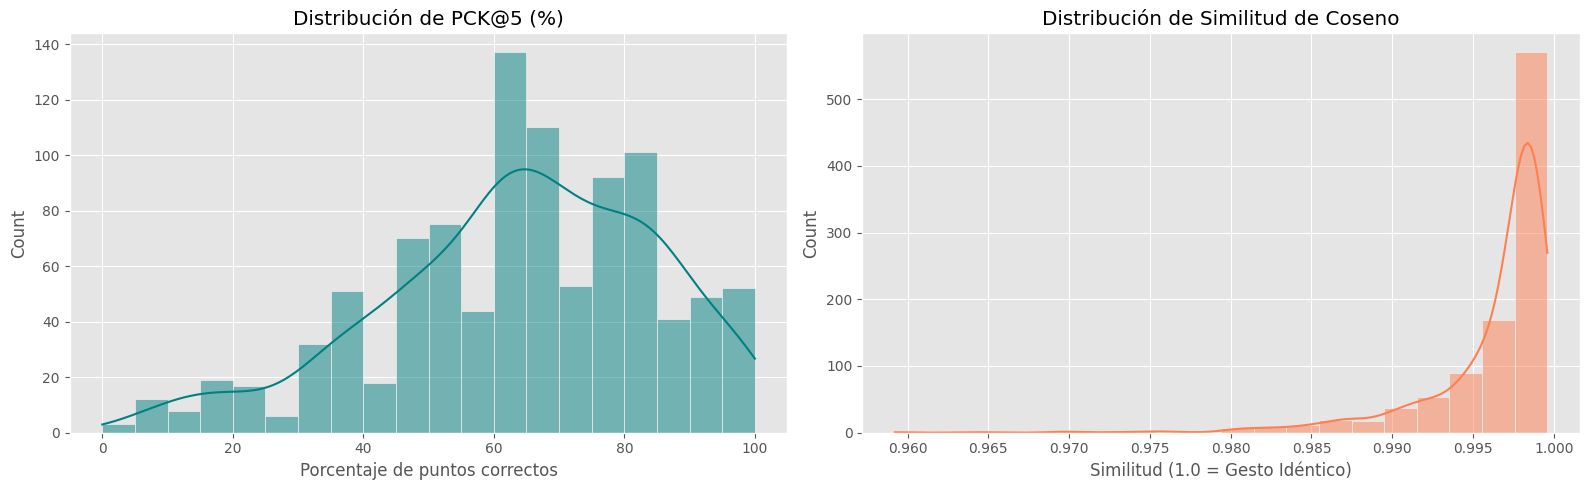

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma PCK@5
sns.histplot(df_valid['pck5'], bins=20, kde=True, ax=ax1, color='teal')
ax1.set_title('Distribución de PCK@5 (%)')
ax1.set_xlabel('Porcentaje de puntos correctos')

# Histograma Similitud de Coseno
sns.histplot(df_valid['cosine'], bins=20, kde=True, ax=ax2, color='coral')
ax2.set_title('Distribución de Similitud de Coseno')
ax2.set_xlabel('Similitud (1.0 = Gesto Idéntico)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_358295/3964281947.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_valid, x='worst_joint', palette='viridis',


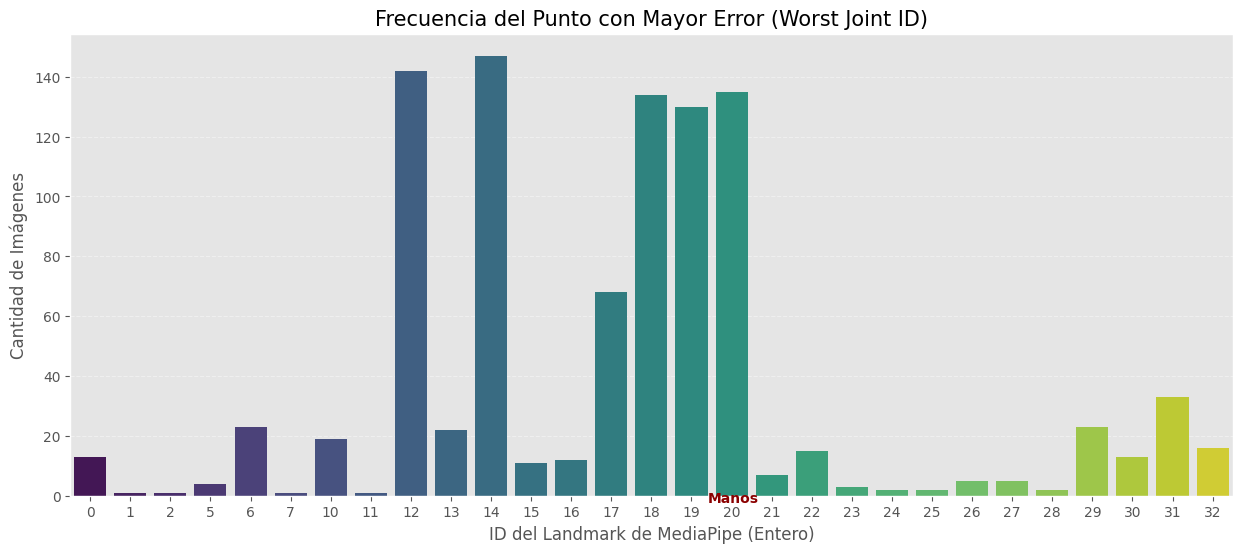

In [5]:
plt.figure(figsize=(15, 6))

# Aseguramos que los IDs sean enteros para evitar decimales en el eje X
df_valid['worst_joint'] = df_valid['worst_joint'].astype(int)

# Graficamos usando el orden natural de los IDs (0 a 32)
sns.countplot(data=df_valid, x='worst_joint', palette='viridis', 
              order=sorted(df_valid['worst_joint'].unique()))

plt.title('Frecuencia del Punto con Mayor Error (Worst Joint ID)', fontsize=15)
plt.xlabel('ID del Landmark de MediaPipe (Entero)', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Opcional: Añadir etiquetas de referencia rápida para los puntos clave
plt.annotate('Manos', xy=(15.5, 0), xytext=(15.5, -5), textcoords='offset points', 
             ha='center', color='darkred', fontweight='bold')
plt.annotate('Pies', xy=(31.5, 0), xytext=(31.5, -5), textcoords='offset points', 
             ha='center', color='darkred', fontweight='bold')

plt.show()

In [30]:
from IPython.display import Image, display

url = "https://www.mdpi.com/applsci/applsci-13-02700/article_deploy/html/images/applsci-13-02700-g001.png"
display(Image(url=url))